# Tests pour mieux comprendre le catalogue eRASS1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import math
import pickle
import os
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
from astropy.cosmology import Planck18
import importlib
from scipy.interpolate import UnivariateSpline
from scipy import integrate
from scipy.optimize import root_scalar

import halo_and_cluster_MF as hcmf
import useful_functions as uf


In [2]:
cosmo = Planck18

In [3]:
importlib.reload(hcmf) ; importlib.reload(uf) 

<module 'useful_functions' from '\\\\dapdc5\\ED282972\\My Documents\\Stage\\Content\\caracterisation selection effects\\useful_functions.py'>

In [4]:
path_eRASS1 = '../DESI_eRass/eRass_Bulbul_2024.fit' #la première table est la table eRosita de départ, enrichie avec des informations d'association avec SDSS-Wen
table_eRASS1 = uf.fits_to_dataframe(path_eRASS1)

## Lien entre F500 et CR500
On en profite pour vérifier notre calcul de CR à partir de Lx (plus pécisément la pertinence de la valeur des paramètres E_peak et S_eROSITA)

### Valeurs

In [5]:
table_eRASS1 = table_eRASS1[table_eRASS1['F500'] < 10000] 

In [6]:
Flux_500 = table_eRASS1['F500'] # ??
CR_500 = table_eRASS1['CR500'] # cts/s
z_eRASS1 = table_eRASS1['zBest'] # redshift
L500 = table_eRASS1['L500'] ; L500 = L500 * 1e42 # erg
Exposure_time = table_eRASS1['Exp'] # s

In [7]:
# Calcul ratio CR computed / CR data
CR_computed = uf.CR_from_LX(L500,z_eRASS1)
ratio_CRcomputed_CRdata = CR_computed / CR_500

print('mean ratio_CRcomputed_CRdata :',np.mean(ratio_CRcomputed_CRdata))
print('std ratio_CRcomputed_CRdata :',np.std(ratio_CRcomputed_CRdata))

mean ratio_CRcomputed_CRdata : 0.7664695006849422
std ratio_CRcomputed_CRdata : 0.4817163662560644


In [8]:
SeROSITA = 2451 * 1e-4 # Surface effective totale de collection des photons avec eROSITA en m^2 (calculé dans le notebook)
E_peak_kev = np.round(2.821 * 0.5740, 3) #localisation du pic dans le spectre du corps noir pour la température moyenne des amas dans eRASS1 (temp moyenne = 0.5470 kev + loi de déplacement de Wien)
E_peak = E_peak_kev * (1.6022 * 1e-9) # unit : erg

print(SeROSITA/(1e4*E_peak))

9448.866980230781


In [9]:
# Calcul du flux avec z et Lx
Flux_500_computed = (L500) / (4 * np.pi * (cosmo.luminosity_distance(z_eRASS1).to('m').value)**2) # flux en erg/s/m^2
ratio_Fluxcomputed_Fluxdata = Flux_500_computed / Flux_500


print('mean ratio_Fluxcomputed_Fluxdata :',np.mean(ratio_Fluxcomputed_Fluxdata))
print('std ratio_Fluxcomputed_Fluxdata :',np.std(ratio_Fluxcomputed_Fluxdata))

mean ratio_Fluxcomputed_Fluxdata : 1.0348462921421339e-10
std ratio_Fluxcomputed_Fluxdata : 4.68650422031754e-11


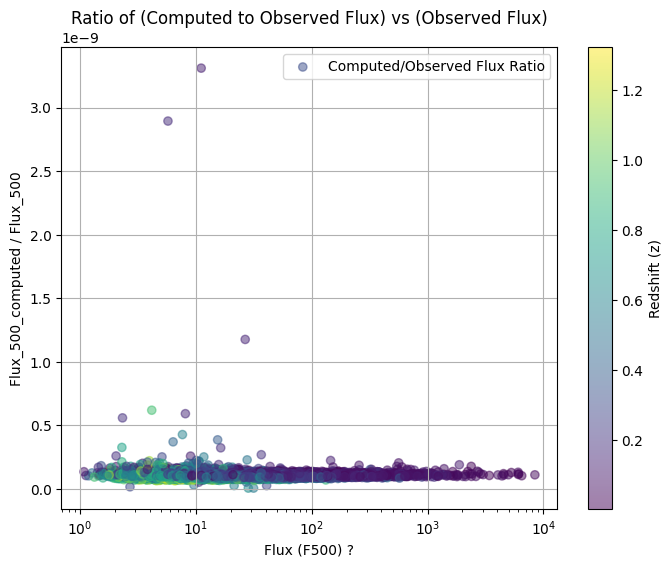

In [10]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(Flux_500, ratio_Fluxcomputed_Fluxdata, c=z_eRASS1, cmap='viridis', alpha=0.5, label='Computed/Observed Flux Ratio')
plt.xscale('log')
plt.xlabel('Flux (F500) ?')
plt.ylabel('Flux_500_computed / Flux_500')
plt.title('Ratio of (Computed to Observed Flux) vs (Observed Flux)')
plt.colorbar(sc, label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

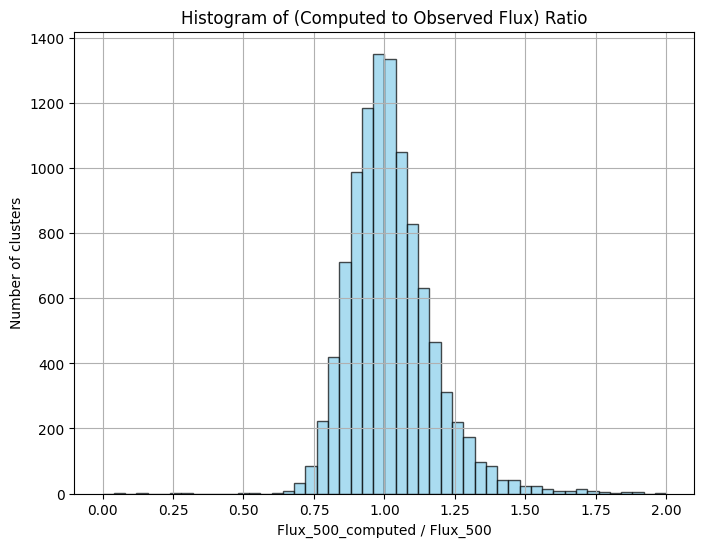

In [11]:
plt.figure(figsize=(8, 6))
plt.hist(ratio_Fluxcomputed_Fluxdata*1e10,range= [0,2], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Flux_500_computed / Flux_500')
plt.ylabel('Number of clusters')
plt.title('Histogram of (Computed to Observed Flux) Ratio')
plt.grid(True)
plt.show()


In [12]:
F500_computed_2 = (CR_500) * (1.6e-9/SeROSITA) # 
F500_data_modif = Flux_500 * 1e-10

ratio_Fluxcomputed_Fluxdata_2 = F500_computed_2 / F500_data_modif


print('mean ratio_Fluxcomputed_Fluxdata_2 :',np.mean(ratio_Fluxcomputed_Fluxdata_2))
print('std ratio_Fluxcomputed_Fluxdata_2 :',np.std(ratio_Fluxcomputed_Fluxdata_2))

mean ratio_Fluxcomputed_Fluxdata_2 : inf
std ratio_Fluxcomputed_Fluxdata_2 : nan


c:\Users\ED282972\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [13]:
# Count NaN values
nan_count = ratio_Fluxcomputed_Fluxdata_2.isna().sum()

# Count inf and -inf values
inf_count = np.isinf(ratio_Fluxcomputed_Fluxdata_2).sum()

# Total count of NaN or inf
total = nan_count + inf_count
print('Total NaN or inf values in ratio_Fluxcomputed_Fluxdata_2:', total)

Total NaN or inf values in ratio_Fluxcomputed_Fluxdata_2: 1799


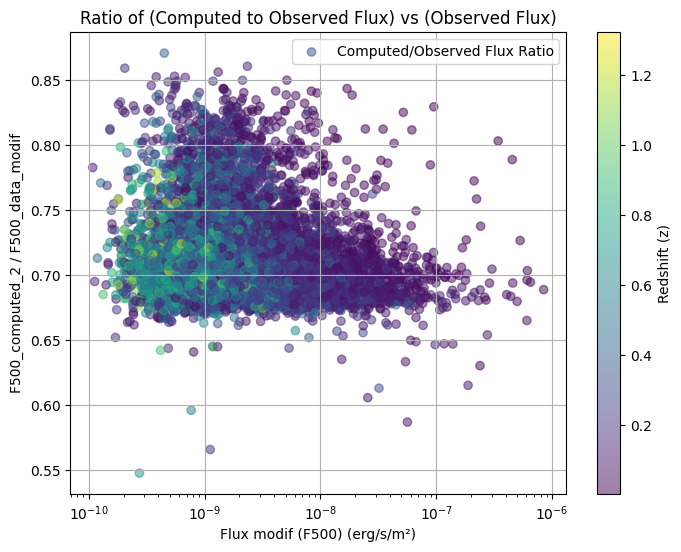

In [14]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(F500_data_modif, ratio_Fluxcomputed_Fluxdata_2, c=z_eRASS1, cmap='viridis', alpha=0.5, label='Computed/Observed Flux Ratio')
plt.xscale('log')
plt.xlabel('Flux modif (F500) (erg/s/m²)')
plt.ylabel('F500_computed_2 / F500_data_modif')
plt.title('Ratio of (Computed to Observed Flux) vs (Observed Flux)')
plt.colorbar(sc, label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

In [15]:
np.mean(F500_computed_2/Flux_500)

np.float64(inf)

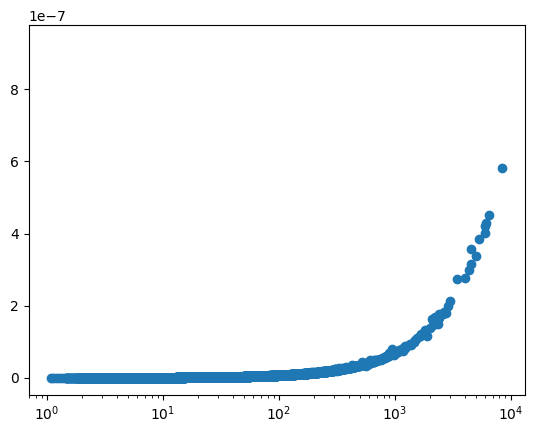

In [16]:
plt.scatter(Flux_500,F500_computed_2)
plt.xscale('log')

### Tracés

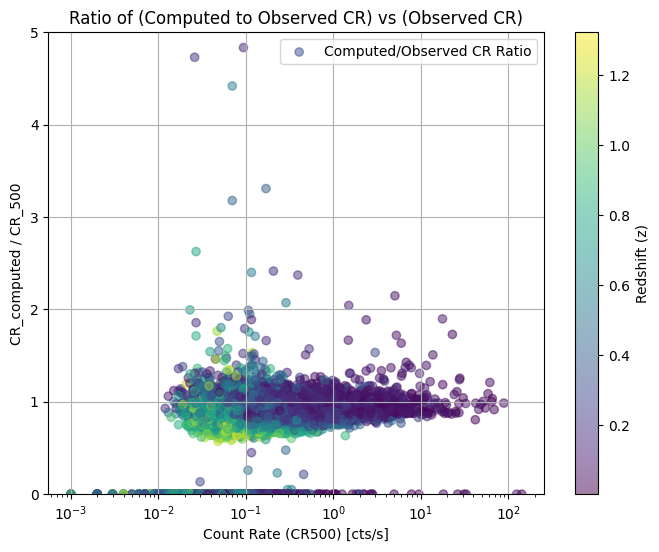

In [17]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(CR_500, ratio_CRcomputed_CRdata, c=z_eRASS1, cmap='viridis', alpha=0.5, label='Computed/Observed CR Ratio')
plt.xscale('log')
plt.xlabel('Count Rate (CR500) [cts/s]')
plt.ylabel('CR_computed / CR_500')
plt.ylim(0, 5) #!!!
plt.title('Ratio of (Computed to Observed CR) vs (Observed CR)')
plt.colorbar(sc, label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

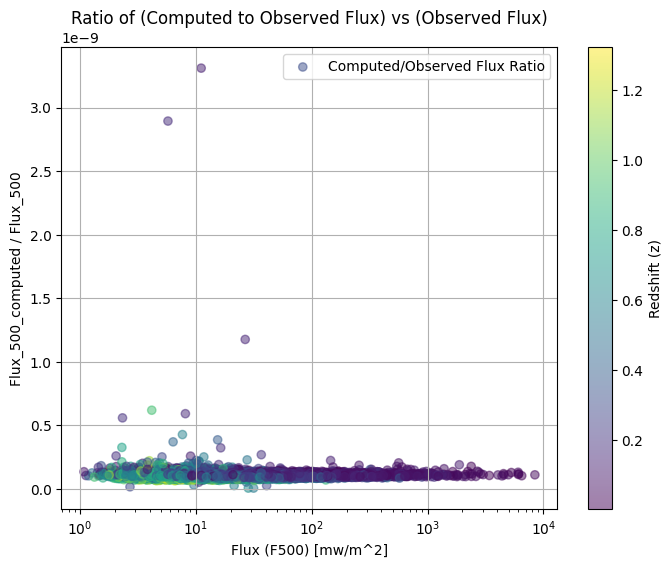

In [18]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(Flux_500, ratio_Fluxcomputed_Fluxdata, c=z_eRASS1, cmap='viridis', alpha=0.5, label='Computed/Observed Flux Ratio')
plt.xscale('log')
plt.xlabel('Flux (F500) [mw/m^2]')
plt.ylabel('Flux_500_computed / Flux_500')
plt.title('Ratio of (Computed to Observed Flux) vs (Observed Flux)')
plt.colorbar(sc, label='Redshift (z)')
plt.grid(True)
plt.legend()
plt.show()

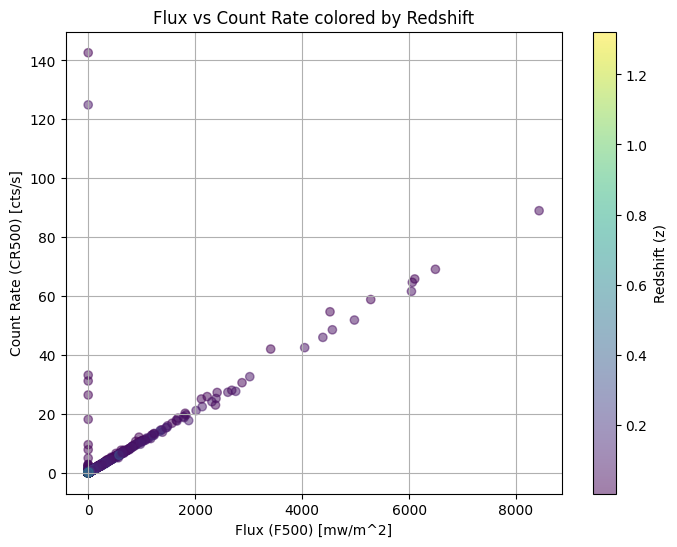

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(Flux_500, CR_500, c=z_eRASS1, cmap='viridis', alpha=0.5)
plt.colorbar(label='Redshift (z)')
plt.xlabel('Flux (F500) [mw/m^2]')
plt.ylabel('Count Rate (CR500) [cts/s]')
plt.title('Flux vs Count Rate colored by Redshift')
#plt.xscale('log')
plt.grid()
plt.show()

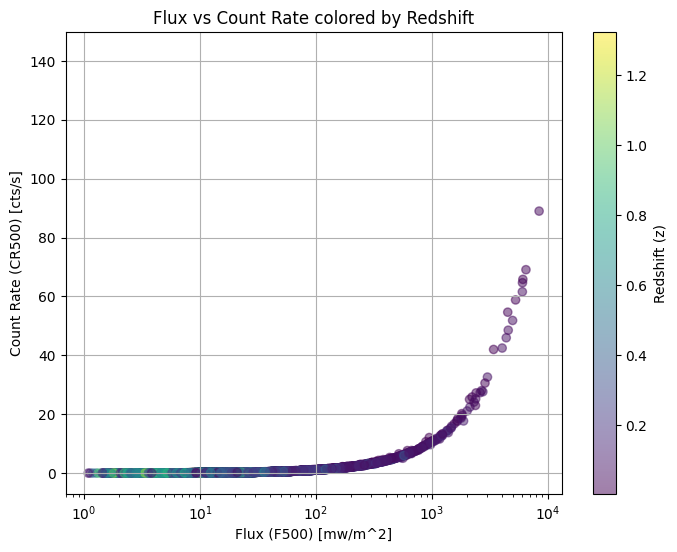

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(Flux_500, CR_500, c=z_eRASS1, cmap='viridis', alpha=0.5)
plt.colorbar(label='Redshift (z)')
plt.xlabel('Flux (F500) [mw/m^2]')
plt.ylabel('Count Rate (CR500) [cts/s]')
plt.title('Flux vs Count Rate colored by Redshift')
plt.xscale('log')
plt.grid()
plt.show()

## Lien entre CR500 et CTS500

In [21]:
CR_500 = table_eRASS1['CR500'] # cts/s
CTS500 = table_eRASS1['CTS500'] # cts
Exposure_time = table_eRASS1['Exp'] # s

In [22]:
CTS500_computed = CR_500 * Exposure_time

In [23]:
np.mean(CTS500_computed/CTS500) # Présence d'outlier ?

np.float64(inf)

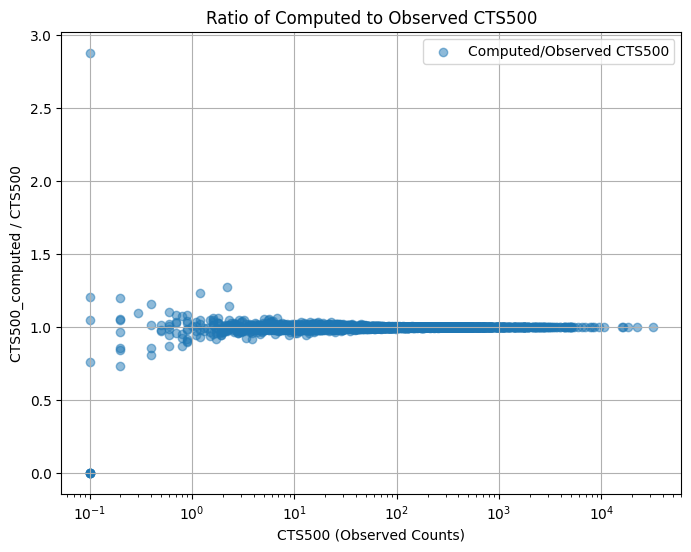

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(CTS500, CTS500_computed/CTS500, alpha=0.5, label='Computed/Observed CTS500')
plt.xscale('log')
plt.xlabel('CTS500 (Observed Counts)')
plt.ylabel('CTS500_computed / CTS500')
plt.title('Ratio of Computed to Observed CTS500')
plt.grid(True)
plt.legend()
plt.show()

## Lien entre Fgas500,M500 et Mgas500


In [25]:
Fgas500 = table_eRASS1['Fgas500'] # fraction de masse de gaz
M500 = table_eRASS1['M500']*1e13 # masse totale de l'amas en Msun
Mgas500 = table_eRASS1['Mgas500']*1e11 # masse de gaz dans l'amas en Msun
Fgas500_computed = Mgas500 / M500 # fraction de masse de gaz calculée
ratio_Fgas = Fgas500_computed / Fgas500


table_eRASS1['ratio_Fgas'] = ratio_Fgas
table_eRASS1_filtered_F = table_eRASS1[table_eRASS1['ratio_Fgas'] < 100] # Filtrage des amas avec ratio_Fgas supérieur à 100


M500_filtered_F = table_eRASS1_filtered_F['M500']*1e13 # masse totale de l'amas en Msun
Mgas500_filtered_F = table_eRASS1_filtered_F['Mgas500']*1e11 # masse de gaz dans l'amas en Msun
Fgas500_filtered_F = table_eRASS1_filtered_F['Fgas500'] # fraction de masse de gaz
ratio_Fgas_filtered_F = table_eRASS1_filtered_F['ratio_Fgas'] # ratio de la fraction de masse de gaz


In [26]:
print('Taille de la table non filtrée :', table_eRASS1.shape)
print('Taille de la table filtrée :', table_eRASS1_filtered_F.shape)

Taille de la table non filtrée : (12242, 20)
Taille de la table filtrée : (10436, 20)


In [27]:
# Count null values in Fgas500
null_count_Fgas500 = Fgas500.isnull().sum() # Nombre d'amas dans le catalogue avec une fraction de masse de gaz strictement nulle
quasi_null_count_Fgas500 = np.shape(np.where(Fgas500 < 1e-10))[1] # Nombre d'amas dans le catalogue avec une fraction de masse de gaz quasi nulle

print('Total number of null values in Fgas500:', null_count_Fgas500)
print('Total number of quasi-null values in Fgas500:', quasi_null_count_Fgas500)

# NOTE : Ca ne devrait pas être possible d'avoir ne serait-ce qu'un seul amas avec une fraction de masse de gaz nulle (sinon on ne devrait pas le détecter en X)

Total number of null values in Fgas500: 0
Total number of quasi-null values in Fgas500: 1806


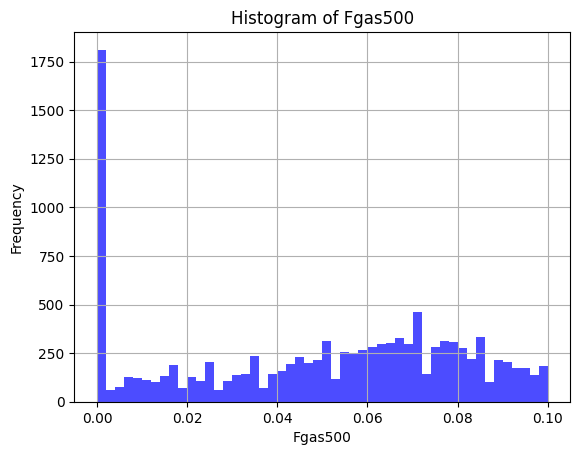

In [28]:
plt.hist(Fgas500, bins=50, range = [0,0.1] ,alpha=0.7, color='blue')
plt.xlabel('Fgas500')
plt.ylabel('Frequency')
plt.title('Histogram of Fgas500')
plt.grid(True)
plt.show()

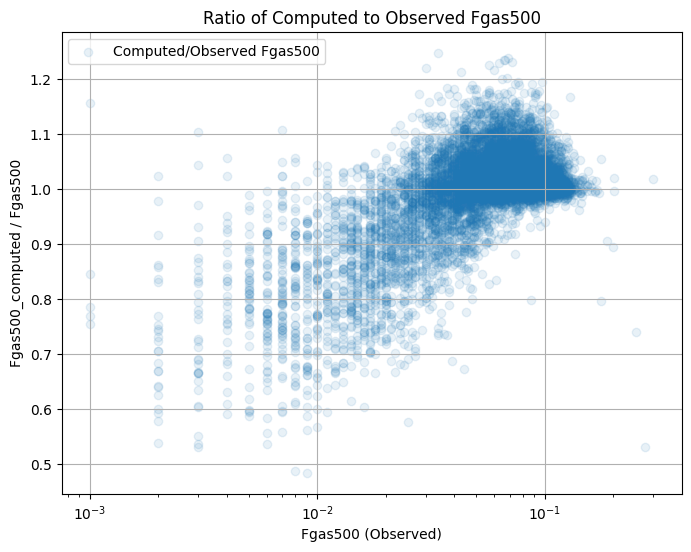

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(Fgas500_filtered_F, ratio_Fgas_filtered_F, alpha=0.1, label='Computed/Observed Fgas500')
plt.xscale('log')
plt.xlabel('Fgas500 (Observed)')
plt.ylabel('Fgas500_computed / Fgas500')
plt.title('Ratio of Computed to Observed Fgas500')
plt.grid(True)
plt.legend()
plt.show()

In [30]:
print('mean ratio_Fgas_filtered_F : ',np.mean(ratio_Fgas_filtered_F)) # moyenne du ratio de la fraction de masse de gaz
print('srd ratio_Fgas_filtered_F : ',np.std(ratio_Fgas_filtered_F)) # moyenne du ratio de la fraction de masse de gaz

mean ratio_Fgas_filtered_F :  0.996603370821777
srd ratio_Fgas_filtered_F :  0.08119090090827649


In [31]:
table_eRASS1.columns

Index(['_Glon', '_Glat', '_RAJ2000', '_DEJ2000', 'Name', 'RAJ2000', 'DEJ2000',
       'Exp', 'zBest', 'CR500', 'CTS500', 'F500', 'L500', 'KT', 'Mgas500',
       'YX500', 'M500', 'Fgas500', 'R500', 'ratio_Fgas'],
      dtype='object')

## Lien entre L et CR

$ CR = \frac{L}{\bar{E}} * \frac{S_{eROSITA}}{4 \pi D_L(z)^2} $

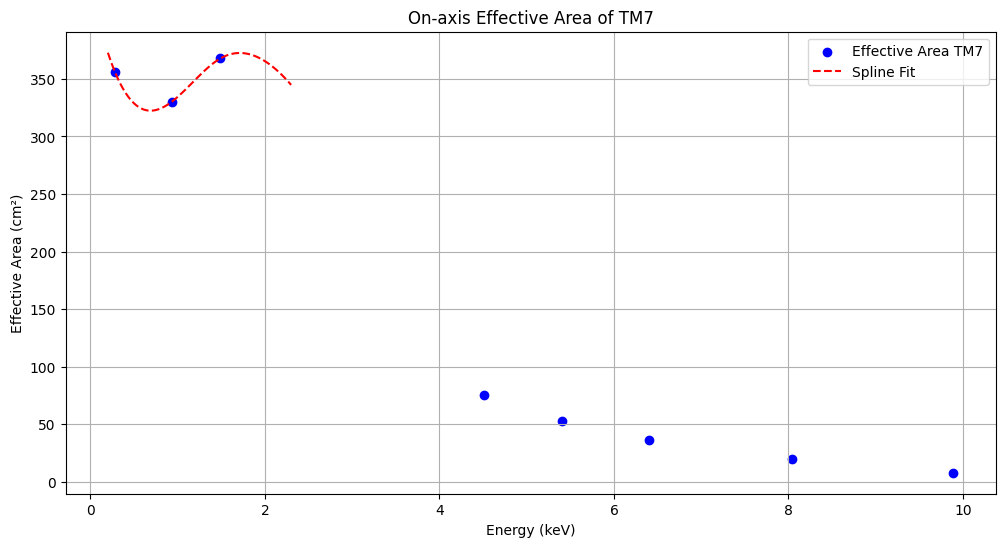

mean_eff_area_2 =  2451.0854099755675 cm²


In [32]:
# Calcul S_eROSITA

# On-axis effective area of TM7 with 3σ errors (Table 5. Predehl et al. 2021)
energy_kev = [0.28,0.93,1.49,4.51,5.41,6.40,8.04,9.89]
eff_area_cm2 = [356.2,330.1, 367.9, 75.3, 52.8, 36.1, 19.41, 7.71]
func_eff_area = UnivariateSpline(energy_kev,eff_area_cm2,s=1e-3)
range_kev = np.linspace(0.2,2.3,100) # range of kev for values of Lx and CR studied in Bulbul et al. 2024
estimation_eff_area = func_eff_area(range_kev)

plt.figure(figsize=(12, 6))
plt.scatter(energy_kev, eff_area_cm2, color='blue', label='Effective Area TM7')
plt.plot(range_kev, estimation_eff_area, color='red', linestyle='--', label='Spline Fit')
plt.xlabel('Energy (keV)')
plt.ylabel('Effective Area (cm²)')
plt.title('On-axis Effective Area of TM7')
plt.legend()
plt.grid()
plt.show()

# Mean effective area over the range 0.2-2.3 keV
mean_eff_area = 7*(integrate.quad(func_eff_area, 0.2, 2.3)[0] / (2.3 - 0.2)) # On multiplie par 7 parce qu'il y a 7 capteurs  
print('mean_eff_area_2 = ',mean_eff_area, "cm²")

In [33]:
# Calcul EE moyen d'un photon (on peut aussi juste prendre E_moy = 1 kev)
mean_KT = table_eRASS1['KT'].mean() #Température X moynenne des amas (en kev)
print('mean_KT =',mean_KT,'kev')
E_peak = np.round(2.821 * mean_KT, 3) # Loi de Wien : position du pic d'énergie maximale : on va considérer que c'est l'énergie de chaque photon détecté dans un premier temps (kev)
print('E_peak = ', E_peak, 'keV')


mean_KT = 0.5728500245057997 kev
E_peak =  1.616 keV


## Figures random

M500_eRASS1_2 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun # M500 masses in Msun


plt.figure(figsize=(12, 6))
plt.plot(L500_eRASS1, M500_eRASS1_2, 'o', markersize=2, alpha=0.5, color='blue')
plt.xscale('log')
plt.xlabel(r'$L_{500}$ (erg.s$^{-1}$)')
plt.ylabel(r'$log_{10}(M_{500}/M_{\odot}$)')
plt.title('Relation entre la masse et la luminosité des amas dans eRASS1')

C:\Users\ED282972\AppData\Local\Temp\ipykernel_7792\508413560.py:2: RuntimeWarning: divide by zero encountered in log10
  M500_eRASS1_2 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun # M500 masses in Msun


Text(0.5, 1.0, 'Relation entre la masse et la luminosité des amas dans eRASS1')

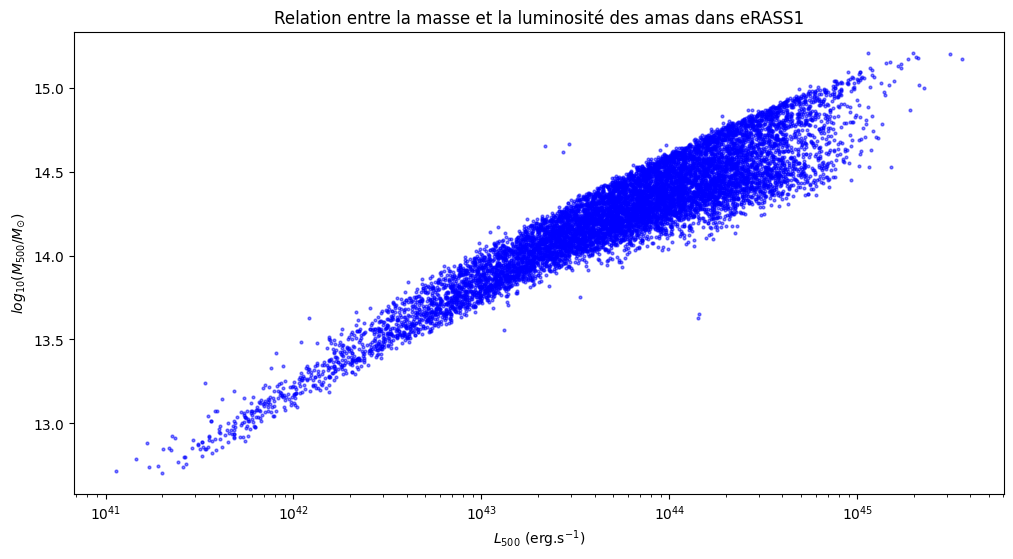

In [34]:
L500_eRASS1 = table_eRASS1['L500'] * 1e42 # erg
M500_eRASS1_2 = np.log10(np.array(table_eRASS1['M500'])*1e13) # Pour ce catalogue, les masses sont données en 10^13 Msun # M500 masses in Msun


plt.figure(figsize=(12, 6))
plt.plot(L500_eRASS1, M500_eRASS1_2, 'o', markersize=2, alpha=0.5, color='blue')
plt.xscale('log')
plt.xlabel(r'$L_{500}$ (erg.s$^{-1}$)')
plt.ylabel(r'$log_{10}(M_{500}/M_{\odot}$)')
plt.title('Relation entre la masse et la luminosité des amas dans eRASS1')

Text(0.5, 1.0, 'Relation entre la masse et le Count-Rate des amas dans eRASS1')

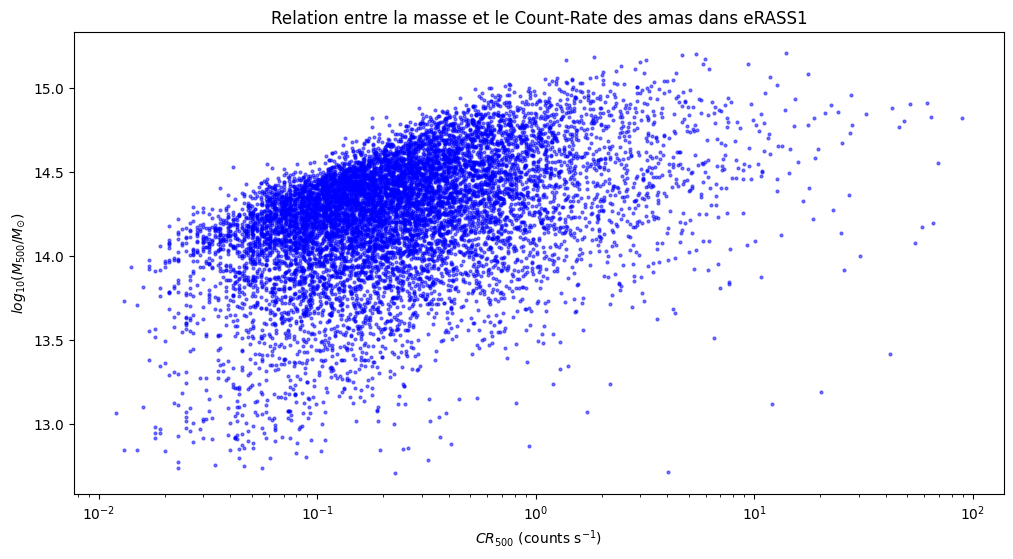

In [35]:
CR500_eRASS1 = table_eRASS1['CR500']

plt.figure(figsize=(12, 6))
plt.plot(CR500_eRASS1, M500_eRASS1_2, 'o', markersize=2, alpha=0.5, color='blue')
plt.xscale('log')
plt.xlabel(r'$CR_{500}$ (counts s$^{-1}$)')
plt.ylabel(r'$log_{10}(M_{500}/M_{\odot}$)')
plt.title('Relation entre la masse et le Count-Rate des amas dans eRASS1')

In [36]:
importlib.reload(hcmf) ; importlib.reload(uf) 

<module 'useful_functions' from '\\\\dapdc5\\ED282972\\My Documents\\Stage\\Content\\caracterisation selection effects\\useful_functions.py'>

In [37]:
from matplotlib.colors import LinearSegmentedColormap
colors = ["blue", "cyan", "green", "darkorange", "orangered","lightcoral"]


In [38]:
range_log10_M_Msun = np.linspace(12.5,15.5,50) # log10(M500/Msun)
range_z = np.linspace(0.1,2.1,5)

CMF_values_z = []

for z in range_z:
    CMF_values_z.append(hcmf.CMF_Bocquet_2016_log10(10**(range_log10_M_Msun), z))

In [39]:
range_z

array([0.1, 0.6, 1.1, 1.6, 2.1])

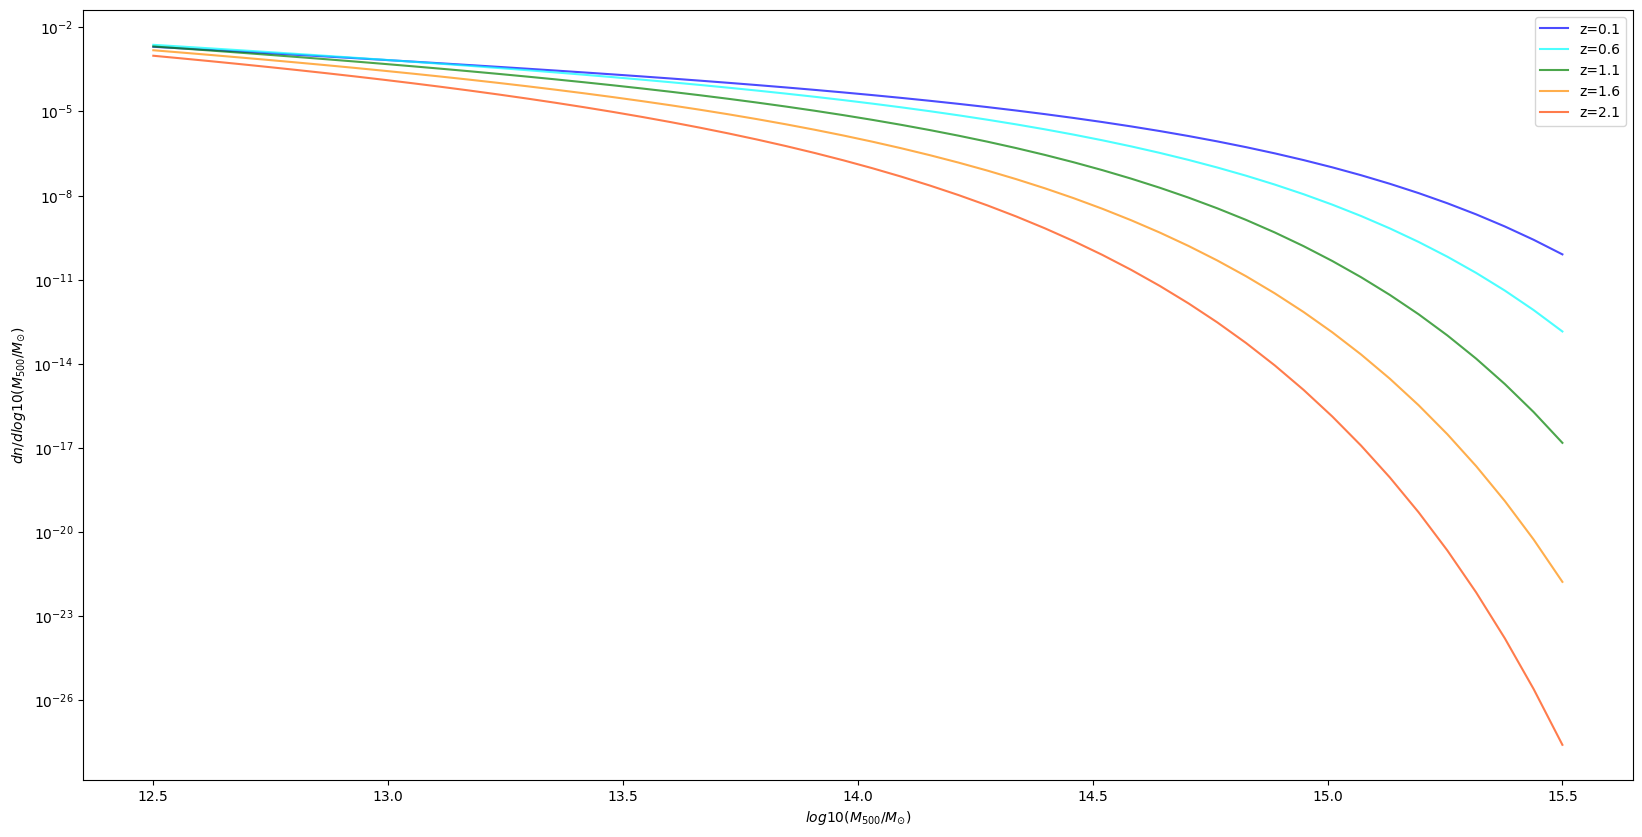

In [40]:
plt.figure(figsize=(20, 10))

for i,ClxF_values in enumerate(CMF_values_z):
    plt.plot(range_log10_M_Msun, CMF_values_z[i], color=colors[i], label = f'z={range_z[i]}' ,alpha=0.7)
    plt.yscale('log')
    plt.xlabel(r'$log10(M_{500}/M_{\odot}$)')
    plt.ylabel(r'$dn / dlog10(M_{500}/M_{\odot})$')

    

plt.legend()

plt.show()